In [10]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
### First, we begin defining the parameters that will be needed to run the analytical equations. The parameters are:
### $\mu_y$ (muy) - Mutation rate of Y
### $N_y$ (vizY) - Number of neighbors that Y can predate 
### $N_x$ (vizX) - Number of sites around an empty site that can leave X descendant
### $d_y$ (dy) - Natural mortality of Y
### $h_x$ (hx) - X efficiency of reproduction
### $h_y$ (hy) - Y efficiency of predation
### To account for two possible foraging area of Y, all variables relate to it will be given by arrays of two entries: The first one ALWAYS will be for $Y_1$ (lower foraging area) and the second related to $Y_2$ (bigger foraging area). The values CANNOT be switched because pair approximations has expressions like
$$
 h_y^{N_{y_2}-N_{y_1}}
$$
### with $N_{y_2}>N_{y_1}$. The value of $h_x = 4$ is fixed throughout all the results of the work. $h_y$ is defined in terms of $N_y$, so every change in the number of neighbors must be accompanied by the change of $h_y$. If you do not want mutation, you need set the mutations rates to 0, as well as defined vizY[1] = hy[1] = 0

In [45]:
#PARAMETERS
muy = 0.05
muz = 0 
vizY = [4,8]
vizX = 4
hy = [1.2/vizY[0],1.2/vizY[1]]
hx = 0.5
dy = 0.15

# Transition probabilities
### The second step of the program is define the transitions probabilities of each state. This expressions are the evaluetion of the averages appearing on (2), and calculated with more detail on Appendix A. Each of the transitions will depend explicity on the value of population of each species. These transitions will be used further on the overall expressions that dictates the temporal evolution of the system. Mean-field terms and pair-approximations terms are separeted in different cells. 

## The suffix "cm" reffers to mean field, end suffix "par" to pair approximation. In the last, some of the transitions has a "subscripit" 2 after "par", reffering to the pair transitions (the probabilities of pair of sites). The only difference is the negative unity on the expoent, since we does have information about one neighbor.

In [46]:
def P0Xcm(P0,PX):
    return P0*(1-(1-hx*PX)**vizX)

def PXYcm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[1]*PY[1]-hy[0]*PY[0])**vizY[0])

def PXY1cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (
        muy/2*(1-(1-PY[1]*hy[1])**vizY[1])+(1-muy/2)*(1-(1-PY[0]*hy[0])**vizY[0]))

def PXY2cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (
        muy/2*(1-(1-PY[0]*hy[0])**vizY[0])+(1-muy/2)*(1-(1-PY[1]*hy[1])**vizY[1]))

In [ ]:
def PX0par(P0,PX0):
    return P0*(1-(1-hx*PX0/P0)**vizX)

def pX0par2(P0,PX0):
    return (1-(1-hx*PX0/P0)**(vizX-1))

def PXYpar(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])

def PXYpar2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))

def PXY1par(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])
            +(1-(1-PXY2/PX)**vizY[1]))*(muy/2*(1-(1-PXY2/PX)**vizY[1])+(1-muy/2)*(1-(1-PXY1/PX)**vizY[0]))

def PXY1par2(PX,PXY1,PXY2): 
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY2/PX)**(vizY[1]-1))+(1-muy/2)*(1-(1-PXY1/PX)**(vizY[0]-1)))

def PXY2par(PX,PXY1,PXY2): 
    return (PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])+(1-(1-PXY2/PX)**vizY[1]))
            *(muy/2*(1-(1-PXY1/PX)**vizY[0])+(1-muy/2)*(1-(1-PXY2/PX)**vizY[1])))
def PXY2par2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY1/PX)**(vizY[0]-1))+(1-muy/2)*(1-(1-PXY2/PX)**(vizY[1]-1)))

# Step 3 - Defining the dynamic equations
### Now we proceed to write the full Master equation for both Mean-field and pair approximation.

### Function "Dinamica_cm" corresponds to mean-field equations. Since it have only 4 variables, the initial condition is already inside this function.
### Its argument "t" is the amount of time of evolution to the system. In the last two lines, we save the values of each population in the arrays media_population_cm  

### The second block of code refers to the pair approximation dynamic. Different from the mean field, the initial condition is made in a different function. It follows the same step by step of Dinamica_cm.

In [48]:
def Dinamica_cm(t):
    global PX, PY, P0
    PX = 0.3
    PY[0] = 0.15
    PY[1] = 0.15
    P0 = 1-PX-PY[0]-PY[1]
    for i in range(t):
        new_PX = PX + P0Xcm(P0, PX) - PXY1cm(PX, PY) - PXY2cm(PX,PY)
        new_PY1 = PY[0] + PXY1cm(PX, PY) - dy*PY[0]
        new_PY2 = PY[1] + PXY2cm(PX, PY) - dy*PY[1]
        new_P0 = 1 - new_PX-new_PY2-new_PY1
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        P0 = new_P0
        vaziocm[i] = P0
        mediaxcm[i] = PX
        mediay1cm[i] = PY[0]
        mediay2cm[i] = PY[1]

In [49]:
def Dinamica_pares(t):
    global P0,PX, PY
    global PX0, PY10, PY20, P00, PXX
    global PXY1, PXY2,PY1Y1, PY1Y2, PY2Y2
    for i in range(t):
        new_PX = PX + PX0par(P0, PX0) - PXYpar(PX, PXY1, PXY2)
        new_PY2 = PY[1] + PXY2par(PX, PXY1, PXY2)
        new_PY1 = PY[0] + PXY1par(PX, PXY1, PXY2)
        new_P0 = 1 - new_PX - new_PY1 - new_PY2
        
        new_PX0 = PX0 + dy*(PXY1+PXY2) + P00*pX0par2(P0, PX0) - (1-hx)*PX0*pX0par2(P0, PX0) - PX0*hx - PX0*PXYpar2(PX, PXY1, PXY2)
        
        new_PY20 = PY20 + dy*(PY1Y2+PY2Y2) + PX0*PXY2par2(PX, PXY1, PXY2) - dy*PY20 - PY20*pX0par2(P0, PX0)

        new_PY10 = PY10 + dy*(PY1Y1+PY1Y2) + PX0*PXY1par2(PX, PXY1, PXY2) - dy*PY10 - PY10*pX0par2(P0, PX0)

        ##################        
       
        new_PXY2 = PXY2 + PY20*pX0par2(P0, PX0) + PXX*PXY2par2(PX, PXY1, PXY2) - dy*PXY2 - hy[1]*PXY2 - (1-hy[1])*PXY2*PXY2par2(PX, PXY1, PXY2)
        new_PXY1 = PXY1 + PY10*pX0par2(P0, PX0) + PXX*PXY1par2(PX, PXY1, PXY2) - dy*PXY1 - hy[0]*PXY1 - (1-hy[0])*PXY1*PXY1par2(PX, PXY1, PXY2)

        ##################
        
        new_PY1Y2 = PY1Y2 + (1-hy[1])*PXY2*PXY1par2(PX, PXY1, PXY2) + (1-hy[0])*PXY1*PXY2par2(PX, PXY1, PXY2) + PXY2*hy[1]*muy/2 + PXY1*hy[0]*muy/2 - 2*dy*PY1Y2

        ##################
       
        P00 = max(0,new_P0 - new_PX0 - new_PY10 - new_PY20) 
        PXX = max(0,new_PX - new_PX0 - new_PXY2 -new_PXY1)  
        PY2Y2 = max(0,new_PY2 - new_PXY2 - new_PY1Y2 - new_PY20)
        PY1Y1 = max(0,new_PY1 - new_PY10 - new_PY1Y2 - new_PXY1)

        ##################
        
        P0 = new_P0
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PX0 = new_PX0
        PY10 = new_PY10
        PY20 = new_PY20
        PXY1 = new_PXY1
        PXY2 = new_PXY2
        PY1Y2 = new_PY1Y2
        vaziopares[i] = P0
        mediaxpares[i] = PX
        mediay1pares[i] = PY[0]
        mediay2pares[i] = PY[1]

## condicao_inicial() is the function that provides the initial condition for the pair approximations dynamics. We proposed a simple disconect initial condition - this means that the probability of a pair is the joint probability of find each of the species. The values of PX and PY are arbitrary

In [54]:
def condicao_inicial():
    global P0, PX, PY
    global PX0, PY10, PY20, P00, PXX, PXY1, PXY2
    global PY1Y1, PY1Y2, PY2Y2
    PX = 0.4
    PY = [0.2, 0.2]
    P0 = 1.0 - (PX + PY[0] + PY[1])
    
    P00  = P0 * P0
    PX0  = PX * P0
    PY10 = PY[0] * P0
    PY20 = PY[1] * P0

    PXX  = PX * PX
    PXY1 = PX * PY[0]
    PXY2 = PX * PY[1]


    PY1Y1 = PY[0] * PY[0]
    PY1Y2 = PY[0] * PY[1]    
    PY2Y2 = PY[1] * PY[1]


## Starting the arrays that will storage the evolution of populations. You must define the total time you will want the systems evolve to define the measurement arrays

In [ ]:
t = 1000
mediaxcm = np.zeros(t)
mediay1cm = np.zeros(t)
mediay2cm = np.zeros(t)
mediaxpares = np.zeros(t)
mediay1pares = np.zeros(t)
mediay2pares = np.zeros(t)
vaziocm = np.zeros(t)
vaziopares = np.zeros(t)
def zera_medidas():
    mediaxcm = np.zeros(t)
    mediay1cm = np.zeros(t)
    mediay2cm = np.zeros(t)
    mediaxpares = np.zeros(t)
    mediay1pares = np.zeros(t)
    mediay2pares = np.zeros(t)
    vaziocm = np.zeros(t)
    vaziopares = np.zeros(t)
condicao_inicial()

# Last step - Making the measurements
### Finally, we can proceed to start the dynamic functions 'Dinamica_pares(t)' and 'Dinamica_cm(t)'. After it, you can plot the evolution of the populations with matplotlib library for example.

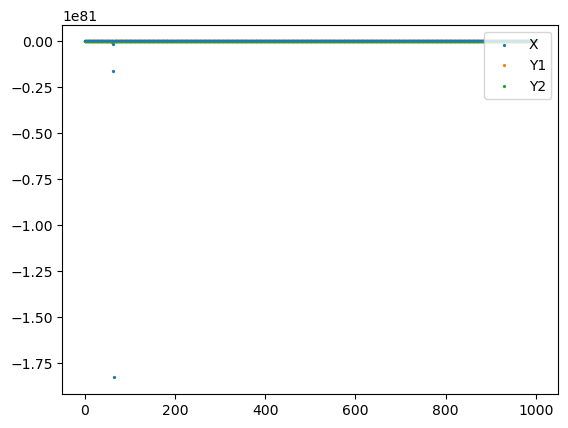

In [52]:
Dinamica_pares(t)
x = np.linspace(0,t,t)
fig, ax = plt.subplots()
ax.scatter(x, mediaxpares, label = 'X', s = 1.75)
ax.scatter(x,mediay1pares, label = 'Y1', s = 1.75)
ax.scatter(x,mediay2pares, label = 'Y2', s = 1.75)
ax.plot(x,np.zeros(t))
ax.legend(loc ='upper right')

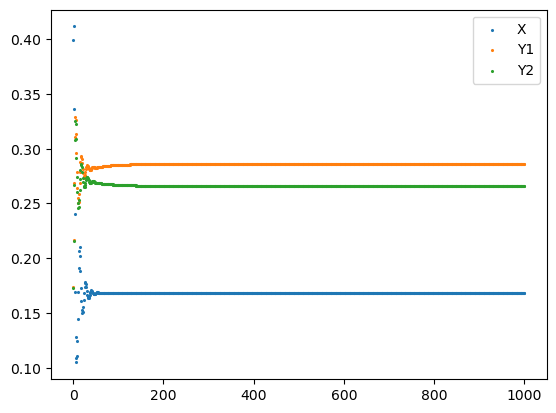

In [36]:
Dinamica_cm(t)
fig, ax = plt.subplots()
ax.scatter(x, mediaxcm, label = 'X', s=1.5)
ax.scatter(x,mediay1cm, label = 'Y1', s=1.5)
ax.scatter(x,mediay2cm, label = 'Y2', s=1.5)
ax.legend()

## More complex measurements can be done too. For example, you can loop through some variable like effiency of predation, $h_y$, or vary the number of neighbors $N_y$.
## For this, we can define new arrays that will storage the equilibrium population (in the example below, I used [-1] in the index, reffering to the last value of population. This only works if the population converge to a well define value, so make sure the dynamics of the system converge to a point!).

In [21]:
valy1 = []
valy2 = []
valx = []
valy1par = []
valy2par = []
valxpar = []
vizY = [4,8]
raio = [4,8,12,20,24,28,36,44,48,56,60,68,80,88]
raios = [4,8,12,20,24,28,36,44,48,56,60,68,80]
for i in range(0,len(raios)):
    zera_medidas()
    vizY[1] = raio[i+1]
    vizY[0] = raio[i]
    hy = [0.4/vizY[0],0.4/vizY[1]]
    Dinamica_cm(t)
    valy2.append(mediay2cm[-1])
    valy1.append(mediay1cm[-1])
    valx.append(mediaxcm[-1])
    condicao_inicial()
    Dinamica_pares(t)
    valy2par.append(mediay2pares[-1])
    valy1par.append(mediay1pares[-1])
    valxpar.append(mediaxpares[-1])


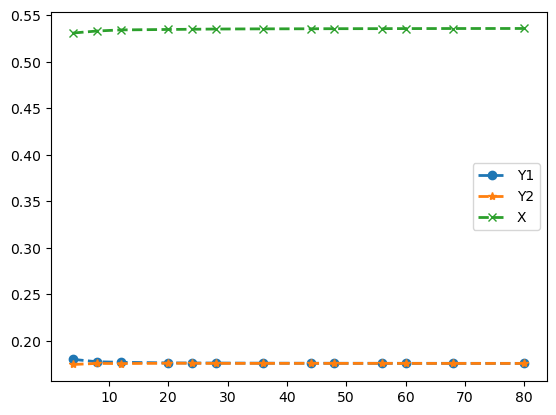

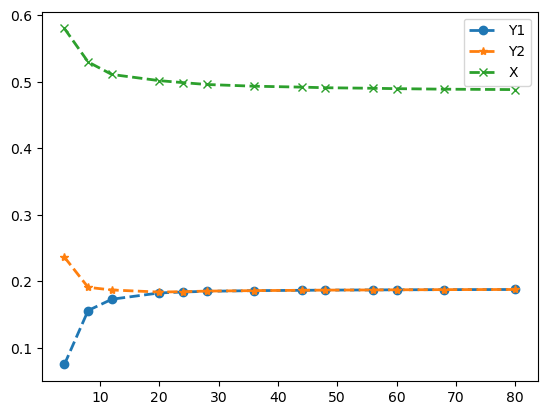

In [22]:
plt.plot(raios,valy1, lw = 2., label = "Y1",marker='o', linestyle='--')
plt.plot(raios,valy2, lw = 2., label = "Y2",marker='*', linestyle='--')
plt.plot(raios,valx, lw = 2., label = "X",marker='x', linestyle='--')
plt.legend()
plt.show()
plt.plot(raios,valy1par, lw = 2., label = "Y1", marker='o', linestyle='--')
plt.plot(raios,valy2par, lw = 2., label = "Y2", marker='*', linestyle='--')
plt.plot(raios,valxpar, lw = 2., label = "X", marker='x', linestyle='--')
plt.legend()